# Phần 1: Tiền Xử Lý Dữ Liệu và Phân Tích Khám Phá (EDA)
Trong Notebook này, chúng ta sẽ kết nối các bảng dữ liệu của Olist, làm sạch dữ liệu và giải quyết 5 bài toán phân tích kinh doanh.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Nạp và Khám phá Dữ liệu
Bộ dữ liệu Olist được phân mảnh thành nhiều bảng. Ta sẽ tải những bảng cần thiết.

In [3]:
# Đọc các bảng dữ liệu
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print("Đã tải xong dữ liệu!")

Đã tải xong dữ liệu!


## 2. Làm Sạch & Ghép Nối Dữ Liệu
Chuyển đổi kiểu dữ liệu datetime, lọc các đơn hàng thành công, và ghép nối các bảng lại với nhau để có góc nhìn toàn diện.

In [4]:
# Chuyển đổi định dạng thời gian
time_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in time_cols:
    orders[col] = pd.to_datetime(orders[col])

# Chỉ giữ lại các đơn hàng 'delivered' (giao thành công) cho phần doanh thu
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Ghép bảng
# 1. orders + order_items
df = pd.merge(orders_delivered, order_items, on='order_id', how='inner')

# 2. + products
df = pd.merge(df, products, on='product_id', how='inner')

# 3. + product category translation (để lấy tên tiếng Anh)
df = pd.merge(df, category_translation, on='product_category_name', how='left')
# Thay thế các category bị thiếu bằng 'Unknown'
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

# 4. + payments (lấy giá trị thanh toán thực tế)
df = pd.merge(df, payments, on='order_id', how='left')

# 5. + customers (lấy vị trí địa lý)
df = pd.merge(df, customers, on='customer_id', how='inner')

df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP


## 3. Phân tích Kinh doanh (5 Câu hỏi)

### Câu 1: Hiệu suất Sản phẩm
**Câu hỏi:** Danh mục sản phẩm (Product Category) nào mang lại Tổng doanh thu (Total Revenue) cao nhất và số lượng đơn hàng bán ra nhiều nhất?

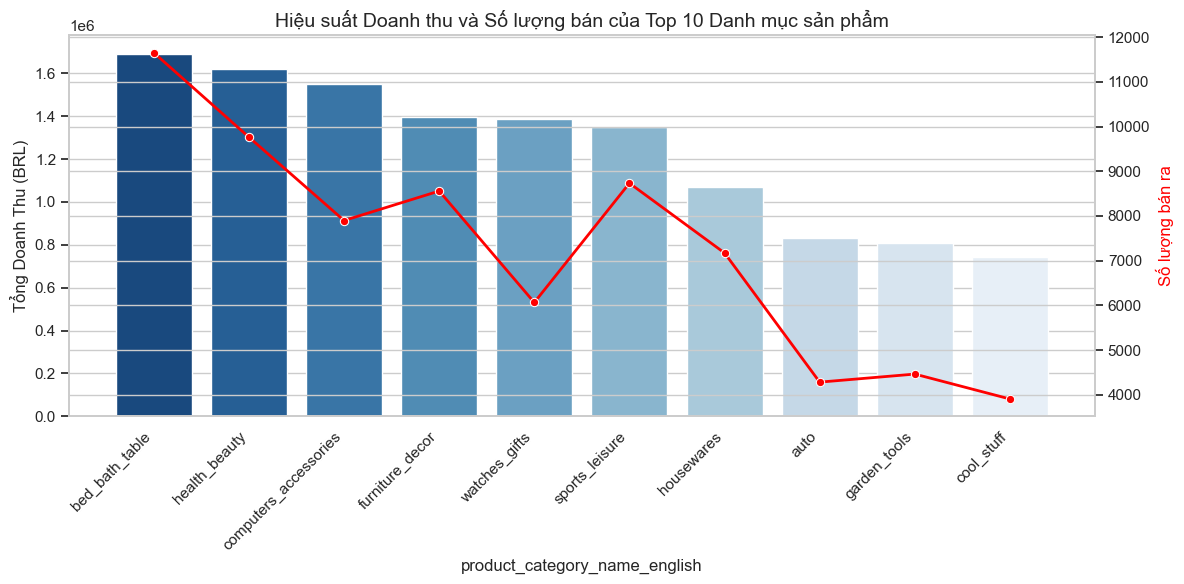

In [5]:
# Nhóm theo danh mục sản phẩm
cat_perf = df.groupby('product_category_name_english').agg({
    'payment_value': 'sum',      # Doanh thu dựa trên thực tế thanh toán
    'order_item_id': 'count'     # Số lượng sản phẩm bán ra
}).rename(columns={'payment_value': 'Total Revenue', 'order_item_id': 'Quantity Sold'})

# Lấy Top 10 danh mục có doanh thu cao nhất
top10_revenue = cat_perf.sort_values(by='Total Revenue', ascending=False).head(10)

# Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục y1: Doanh thu (Cột)
sns.barplot(x=top10_revenue.index, y='Total Revenue', data=top10_revenue, ax=ax1, palette='Blues_r')
ax1.set_ylabel('Tổng Doanh Thu (BRL)', fontsize=12)
ax1.set_title('Hiệu suất Doanh thu và Số lượng bán của Top 10 Danh mục sản phẩm', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Trục y2: Số lượng bán ra (Đường)
ax2 = ax1.twinx()
sns.lineplot(x=top10_revenue.index, y='Quantity Sold', data=top10_revenue, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Số lượng bán ra', fontsize=12, color='red')

plt.tight_layout()
plt.show()

> **📌 Insight:** Biểu đồ kết hợp (Cột - Doanh thu, Đường - Số lượng bán) cho thấy những danh mục mũi nhọn như `health_beauty`, `watches_gifts`, `bed_bath_table`. Tuy nhiên, `bed_bath_table` dù có số lượng bán rất cao nhưng doanh thu chỉ đứng thứ 3, cho thấy giá trị trung bình mỗi sản phẩm của nhóm này khá thấp so với `watches_gifts`.

### Câu 2: Hành vi Khách hàng
**Câu hỏi:** Tỷ lệ khách hàng quay lại mua hàng (Retention Rate) của doanh nghiệp là bao nhiêu, và những khách hàng trung thành thường có xu hướng chi tiêu bao nhiêu?

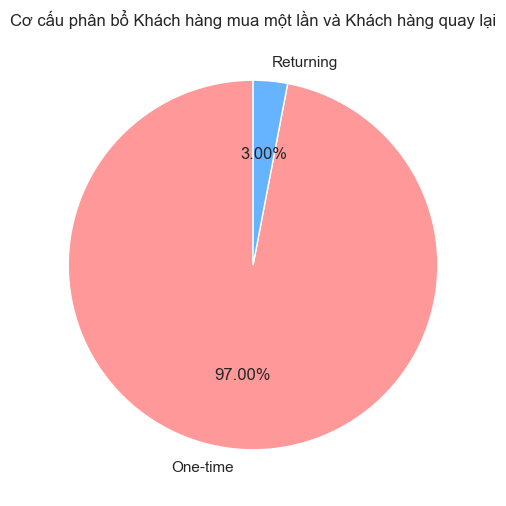

Mức chi tiêu trung bình (BRL):
 customer_type
One-time     204.336787
Returning    454.135684
Name: payment_value, dtype: float64


In [6]:
# Tính toán lượng đơn hàng cho mỗi khách hàng (dựa trên customer_unique_id)
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']

# Phân loại: 1 đơn là Khách mới/Mua 1 lần, >= 2 là Khách quay lại
customer_orders['customer_type'] = np.where(customer_orders['total_orders'] > 1, 'Returning', 'One-time')

retention_counts = customer_orders['customer_type'].value_counts()

# Trực quan hóa tỷ lệ khách quay lại
plt.figure(figsize=(6, 6))
plt.pie(retention_counts, labels=retention_counts.index, autopct='%1.2f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Cơ cấu phân bổ Khách hàng mua một lần và Khách hàng quay lại')
plt.show()

# Tính mức chi tiêu trung bình
cust_spending = df.groupby('customer_unique_id')['payment_value'].sum().reset_index()
cust_data = pd.merge(customer_orders, cust_spending, on='customer_unique_id')

avg_spend = cust_data.groupby('customer_type')['payment_value'].mean()
print("Mức chi tiêu trung bình (BRL):\n", avg_spend)

> **📌 Insight:** Tỷ lệ khách hàng quay lại (Returning) chỉ chiếm khoảng 3%, một con số vô cùng thấp. Điều này cho thấy Olist hoặc các người bán trên Olist đang gặp vấn đề lớn trong việc giữ chân khách hàng (có thể do thiếu thẻ thành viên, thiếu mã giảm giá hoặc trải nghiệm sau mua chưa tốt). Tuy nhiên, nhóm khách quay lại có mức chi tiêu trung bình cao hơn đáng kể so với khách mua 1 lần.

### Câu 3: Phân tích Thời điểm
**Câu hỏi:** Khung giờ nào trong ngày hoặc ngày nào trong tuần có số lượng đơn hàng (Order Volume) cao nhất, và giá trị trung bình của mỗi đơn hàng (AOV) trong thời gian đó là bao nhiêu?

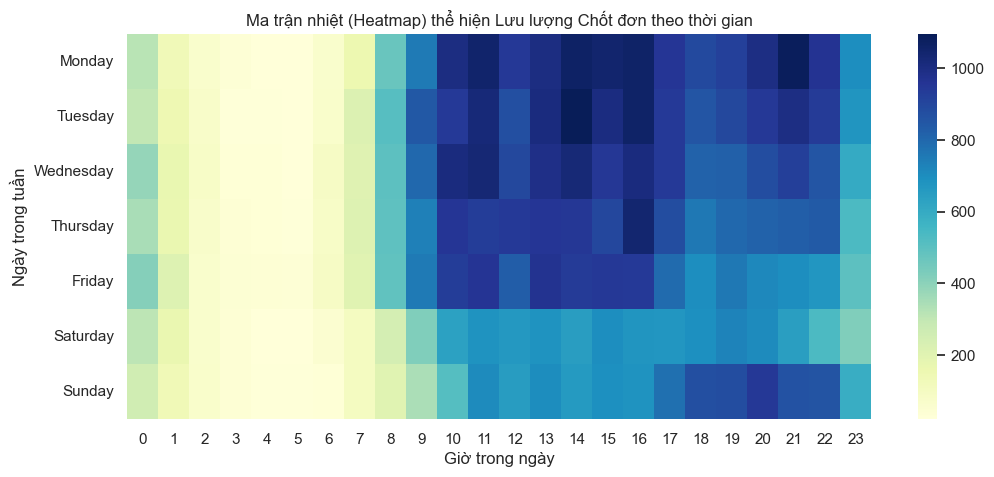

Top 3 khung giờ chốt đơn cao nhất:
     purchase_dayOfWeek  purchase_hour  order_count  total_revenue         AOV
134            Tuesday             14         1095      250896.99  229.129671
45              Monday             21         1083      223868.84  206.711764
38              Monday             14         1063      230646.62  216.977065


In [7]:
# Trích xuất Giờ và Ngày trong tuần từ thời điểm mua hàng
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['purchase_dayOfWeek'] = df['order_purchase_timestamp'].dt.day_name()

# Sắp xếp thứ tự ngày trong tuần
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Gom nhóm tính số lượng đơn và doanh thu
time_analysis = df.groupby(['purchase_dayOfWeek', 'purchase_hour']).agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()

# Tính AOV
time_analysis['AOV'] = time_analysis['total_revenue'] / time_analysis['order_count']

# Tạo pivot table cho Heatmap (Số lượng đơn)
heatmap_data = time_analysis.pivot(index='purchase_dayOfWeek', columns='purchase_hour', values='order_count')
heatmap_data = heatmap_data.reindex(days_order)

# Vẽ Heatmap cho Số lượng đơn hàng
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
plt.title('Ma trận nhiệt (Heatmap) thể hiện Lưu lượng Chốt đơn theo thời gian')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Ngày trong tuần')
plt.show()

# In top 3 thời điểm có Order Volume lớn nhất kèm AOV
top3_times = time_analysis.sort_values(by='order_count', ascending=False).head(3)
print("Top 3 khung giờ chốt đơn cao nhất:\n", top3_times)

> **📌 Insight:** Mật độ mua sắm tập trung dày đặc nhất vào các ngày trong tuần (Thứ 2 đến Thứ 6) từ 10h sáng đến 16h chiều, và đạt đỉnh cao nhất ở khoảng 14h-16h. Buổi tối và cuối tuần (Thứ 7, CN) có số lượng đơn giảm mạnh. Giá trị trung bình mỗi đơn hàng (AOV) dao động ổn định. Doanh nghiệp nên tập trung chạy quảng cáo và flash sale vào các khung giờ hành chính này.

### Câu 4: Phân bổ Địa lý & Vận chuyển
**Câu hỏi:** Khách hàng ở các khu vực địa lý khác nhau có xu hướng ưu tiên những phương thức thanh toán nào, tác động thế nào đến thời gian hoàn thành đơn?

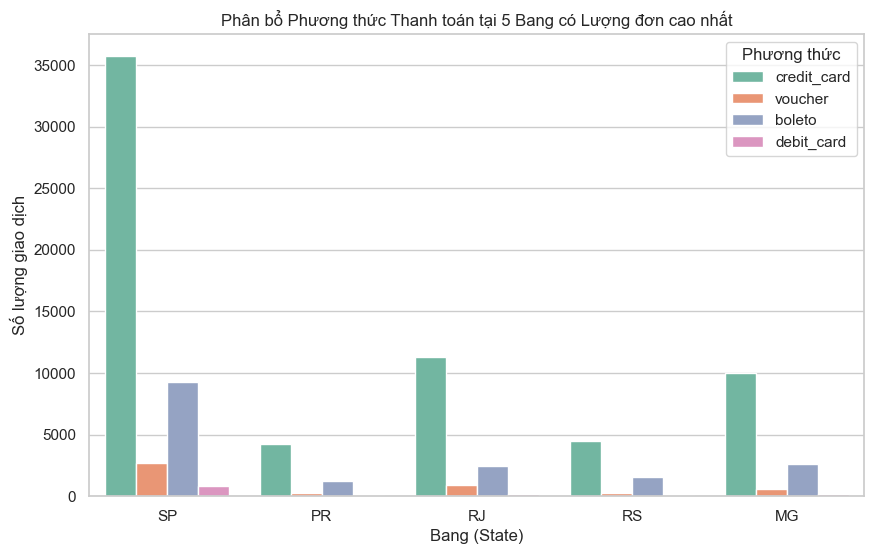

Thời gian giao hàng trung bình (ngày) tại top 5 bang:
 customer_state
SP     8.270972
MG    11.496162
PR    11.516530
RS    14.693200
RJ    14.763128
Name: delivery_days, dtype: float64


In [8]:
# Tính thời gian giao hàng thực tế (tính bằng ngày)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Phân bổ phương thức thanh toán theo Bang (Top 5 bang có nhiều đơn nhất)
top5_states = df['customer_state'].value_counts().head(5).index
df_top_states = df[df['customer_state'].isin(top5_states)]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_top_states, x='customer_state', hue='payment_type', palette='Set2')
plt.title('Phân bổ Phương thức Thanh toán tại 5 Bang có Lượng đơn cao nhất')
plt.xlabel('Bang (State)')
plt.ylabel('Số lượng giao dịch')
plt.legend(title='Phương thức')
plt.show()

# Trung bình thời gian giao hàng theo bang
avg_delivery_state = df_top_states.groupby('customer_state')['delivery_days'].mean().sort_values()
print("Thời gian giao hàng trung bình (ngày) tại top 5 bang:\n", avg_delivery_state)


> **📌 Insight:** `credit_card` (Thẻ tín dụng) là phương thức thanh toán áp đảo ở tất cả các bang, tiếp theo là `boleto` (một dạng hóa đơn trả sau phổ biến ở Brazil). Khách hàng ở bang SP (São Paulo) có thời gian nhận hàng nhanh nhất (khoảng 8 ngày), do SP là trung tâm kinh tế lớn, mật độ người bán cao. Các bang xa hơn (như RS, MG) tốn đến 11-14 ngày để giao hàng.

### Câu 5: Phân tích Rủi ro
**Câu hỏi:** Đâu là những nguyên nhân phổ biến nhất (dựa trên dữ liệu đánh giá, số ngày giao chậm) dẫn đến việc khách hàng có trải nghiệm tệ / đơn hàng bị hoàn trả?

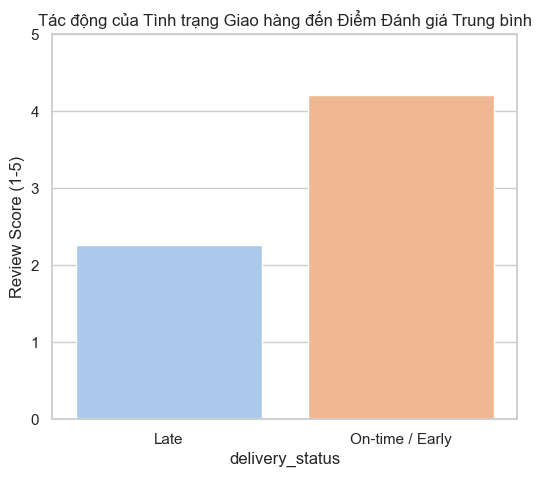

Tỷ lệ các mốc điểm đánh giá đối với đơn hàng Giao Trễ:
 review_score
1.0    54.404778
2.0     8.633094
3.0    10.574182
4.0    10.004072
5.0    16.383874
Name: proportion, dtype: float64


In [9]:
# Merge với bảng reviews để phân tích điểm đánh giá
df_reviews = pd.merge(df, reviews[['order_id', 'review_score']], on='order_id', how='left')

# Tính độ trễ giao hàng: Thời gian giao thực tế trừ đi thời gian dự kiến
df_reviews['delay_days'] = (df_reviews['order_delivered_customer_date'] - df_reviews['order_estimated_delivery_date']).dt.days

# Phân loại giao hàng: Sớm (Âm), Đúng hạn (0), Trễ (Dương)
df_reviews['delivery_status'] = np.where(df_reviews['delay_days'] > 0, 'Late', 'On-time / Early')

# Thống kê Review Score trung bình theo tình trạng giao hàng
review_by_delay = df_reviews.groupby('delivery_status')['review_score'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(x='delivery_status', y='review_score', data=review_by_delay, palette='pastel')
plt.title('Tác động của Tình trạng Giao hàng đến Điểm Đánh giá Trung bình')
plt.ylabel('Review Score (1-5)')
plt.ylim(0, 5)
plt.show()

# Chi tiết phân bố review_score ở nhóm Late
late_reviews = df_reviews[df_reviews['delivery_status'] == 'Late']['review_score'].value_counts(normalize=True).sort_index()
print("Tỷ lệ các mốc điểm đánh giá đối với đơn hàng Giao Trễ:\n", late_reviews * 100)

> **📌 Insight:** Giao hàng trễ (Late) là thủ phạm chính tàn phá trải nghiệm khách hàng. Điểm đánh giá trung bình của các đơn giao trễ sụt giảm nghiêm trọng xuống mức ~2.3/5, với hơn 50% số đơn giao trễ bị khách hàng đánh giá 1 sao. Rủi ro mất khách và bị hoàn tiền (Refund) nằm lớn nhất ở khâu vận chuyển, Olist cần có hình phạt nghiêm với các Carrier (Nhà vận chuyển) không đáp ứng cam kết thời gian.